In [10]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict,Literal,Annotated
from langchain.chat_models import init_chat_model
from pydantic import BaseModel,Field
import operator
from langchain_core.messages import HumanMessage,AIMessage,SystemMessage,BaseMessage

In [11]:
load_dotenv()

True

In [12]:
evaluator_llm = init_chat_model("google_genai:gemini-3.5-flash")
generator_llm = init_chat_model("google_genai:gemini-3.5-flash")
optimizer_llm = init_chat_model("google_genai:gemini-3.5-flash")

In [13]:
class TweetEvaluation(BaseModel):
    evaluation: Literal["approved","needs_improvement"] = Field(...,description="Final evaluation result")
    feedback: str= Field(...,description="Feedback for the tweet")

In [14]:
structured_evaluator_llm = evaluator_llm.with_structured_output(TweetEvaluation)

In [15]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal["approved","needs_improvement"]
    feedback:str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str],operator.add]
    feedback_history: Annotated[list[str],operator.add]

In [16]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [ ]:
def evaluate_tweet(state: TweetState):

    # prompt
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?
2. Humor – Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness – Is it short, sharp, and scroll-stopping?
4. Virality Potential – Would people retweet or share it?
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]

    response = structured_evaluator_llm.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [18]:
def optimize_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [19]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

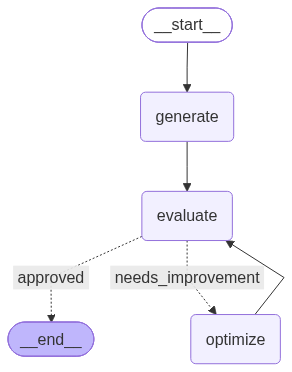

In [20]:
graph = StateGraph(TweetState)

graph.add_node('generate', generate_tweet)
graph.add_node('evaluate', evaluate_tweet)
graph.add_node('optimize', optimize_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluate')

graph.add_conditional_edges('evaluate', route_evaluation, {'approved': END, 'needs_improvement': 'optimize'})
graph.add_edge('optimize', 'evaluate')

workflow = graph.compile()

workflow

In [27]:
initial_state = {
    "topic": "Age of AGI",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

In [28]:
result

{'topic': 'Age of AGI',
 'tweet': [{'type': 'text',
   'text': 'We’re burning a nuclear reactor’s worth of compute just so a god-like superintelligence can help me decide if "Sounds good!" needs an exclamation point.',
   'extras': {'signature': 'EuIxCt8xAWkUfROV3s1NWzU44A7bDp83VZmEB7BBy5juRQoQKcWcgiIkz6R6UMT94Sg2zpGHe/j+rgX5dck8L8kwjDOr5mCoWqHI3Zve5Dc5sXVGk1V14UIiCjR4Ylj4lWTtmQP/6lgcSHztNohPAUrCIaawBw9P4iUJZeRoriqUE/mWVPnIvT8jaYkUv3efuLPwMzxHOdaVE6mBaU2DADvHL4p+wgmQwtzS6jaqX30Neu5G+k18bIiEMA7AZFNzexnkjP2E972wxVaySX8XB0HVEsCJpKc17qXbYy3ndnXSxPDRVn4xK788iyY2s3z1WzMoCEN0fr7HpdW/AOYUxlpxl1jiJPnQizFbUFJt3oVe4HvsFnizuXNMcce5SB/LhKZwTIwHQ7g7N7UDesFcZn0t89oaeMjvkKjUG/QbbTVGBH8OGBKzw5P6dbo3GYWRS3qPV8WgyLtkDCz2C5Loz2+8q7SpQ3BObDBTum5r5ZNjk9S77WS308qq5LAqxSla2qEK1izzqJ6TY9hkxbq3v7GBSSW5hMBLaGOWRnuVKPikXGICNXkRYSj79Ft6WKNu96vK8Va6pmFy0bZhW4qvRWiB0BI3KkWozJC68Q2ckiKgKHAHA5ziEN4DySUvMDM/pjh41SaRrSu8JEO/+vv1j2EFUjkbyBEjGElbnNyXKYEIQXfXUKr9EG9i4jzTADfLGDjS/0YBpJAjLw+wBZI57Wp+gtra4YHevAvntsrJMWYNC0+JG

In [30]:
for tweet in result['tweet_history']:
    print(tweet)

[{'type': 'text', 'text': 'We spent billions bringing on the Age of AGI so a god-like superintelligence capable of solving quantum physics could draft my "sorry for the late reply" emails.', 'extras': {'signature': 'Et4jCtsjAWkUfRPRdWaqPOntYWD+ynaJT7rktvQKwx/pB/ZtbX4Oc+kS5hLy5kYVDMxddiYy+t+dlP6jERcdJ7BQE2iRcybSuVH2YSInNJKQ/K2+T/GQYoGYS52vg01l1rAnscvTveBj72mzgeqOIPBv/A0PxqHgK1m6DmqQ8ebaLaidZvHukEISv1BH1mZuSb/HIM89YY1GyXAEc7b9o+Jx9NsQfaMMtrUZ0Si01SU5jTJgzrH7HWIDotcvrhrYLbOfQEViwyBXDzlHwtA6LQBIB+nZ6xhVacqHP3n+z6A1xvcU2tGzL7ripyX5j+wgBw2e1omkwr2CMKWdETy3osPU4vkn+e3DPpG+CxX5/b4tmaUK5ZMS17Dvu0m5E0raV6Ei1Ekq2c8S8GvC458wcMqABDOcVXL89lDT0IzsjKMWnzb0Ng8Nrpob6AjmrgEBXNuDd1g+djqzO3evwdQZVxpoi4gHzb02q8v2tEvY9BijOJvfhW27U2zZiQDiDChP18DyjsnUCHcmsFn6UwemlAi5c5PTmEQyTtB1kf+ceDmQdW8jJBA4xfhQfmMUaFRZes4laDg97Ul/JHTuWDOG7jZ6mvhpsNbdsLfxIXP687LGfzTZUakDlNFLPMRYyLDHUO6HaqngulUkHS4fc/MCFkADiQHmv5Z0LWJkv+gCshduGEBHs9dNHJqHlNxT6a/+7AcN+7HcgbTt01Aw8FfYjJ5zCuWk1Fqpzcj7rA45SUgxVBYk6n4lvSaXnFbHFRJ9gj5ZkOHTSQXaGN2h